Load libaries and load data 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/telco-churn.csv')
# Display the shape of the DataFrame
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

print(df.info())
print(df.head())



The dataset has 7043 rows and 21 columns.
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBi

In [7]:
#count how many customers have stayed and how many have churned
churn_counts = df['Churn'].value_counts()
print(churn_counts)



Churn
No     5174
Yes    1869
Name: count, dtype: int64


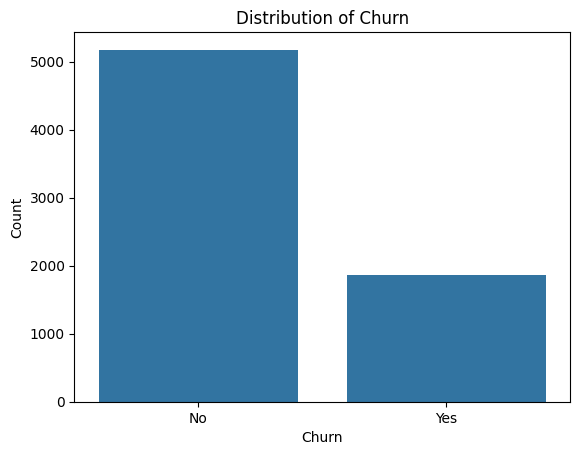

In [8]:

#visualizing the imbalance in the target variable
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

Note:  Notice that more people stayed than left. This is 'Imbalanced Data'. If we don't handle this, the AI will be biased towards the majority.

In [14]:
# Prepare the data for modeling
from sklearn.model_selection import train_test_split

# X contains all features except the target; y is the target label
x = df.drop('Churn', axis=1).copy()
y = df['Churn']

# Drop identifier column (not predictive and non-numeric)
if 'customerID' in x.columns:
    x = x.drop(columns=['customerID'])

# Convert TotalCharges to numeric if loaded as text (common in this dataset)
if 'TotalCharges' in x.columns:
    x['TotalCharges'] = pd.to_numeric(x['TotalCharges'], errors='coerce')
    x['TotalCharges'] = x['TotalCharges'].fillna(x['TotalCharges'].median())

# One-hot encode only categorical columns so the model receives numeric input
categorical_cols = [
    col for col in x.columns
    if x[col].dtype == 'object' or pd.api.types.is_string_dtype(x[col]) or isinstance(x[col].dtype, pd.CategoricalDtype)
]
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

# Split 20% of the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set has {x_train.shape[0]} rows and {x_train.shape[1]} columns.")
print(f"Testing set has {x_test.shape[0]} rows and {x_test.shape[1]} columns.")
print(f"Number of encoded features: {x.shape[1]}")

Training set has 5634 rows and 30 columns.
Testing set has 1409 rows and 30 columns.
Number of encoded features: 30


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest Classifier with 100 trees and a random state for reproducibility
model= RandomForestClassifier(n_estimators=100, random_state=42)
# Fit the model to the training data
model.fit(x_train, y_train)

print("Model training completed.")

Model training completed.


In [17]:
y_pred = model.predict(x_test)

#look 5 examples of the predicted values
print("Prediction (0 = remain, 1 = leave):", y_pred[:5])
print("Actual values (Real values ):", y_test.values[:5])

Prediction (0 = remain, 1 = leave): ['No' 'Yes' 'No' 'No' 'No']
Actual values (Real values ): <StringArray>
['No', 'No', 'No', 'No', 'No']
Length: 5, dtype: str


In [ ]:
#accuracy evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy= accuracy_score(y_test, y_pred)
print(f" Modal Accuracy: { accuracy*100:.2f}%")

 Modal Accuracy: 78.64%


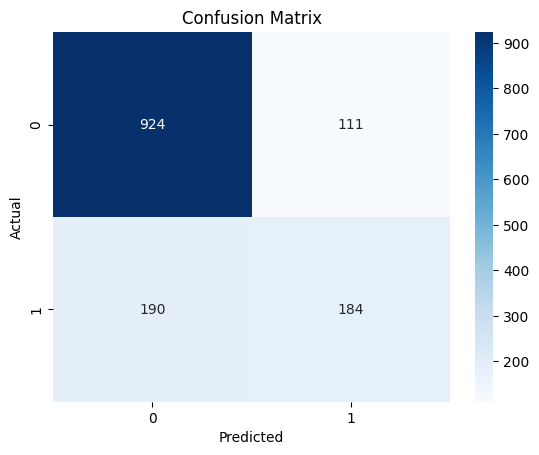

Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



In [22]:
#consfusion matrix
cm= confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))

                           Feature  Importance
3                     TotalCharges    0.192096
1                           tenure    0.174733
2                   MonthlyCharges    0.168413
28  PaymentMethod_Electronic check    0.038771
10     InternetService_Fiber optic    0.038641
25               Contract_Two year    0.030176
4                      gender_Male    0.028321
13              OnlineSecurity_Yes    0.028191
26            PaperlessBilling_Yes    0.025617
5                      Partner_Yes    0.023326


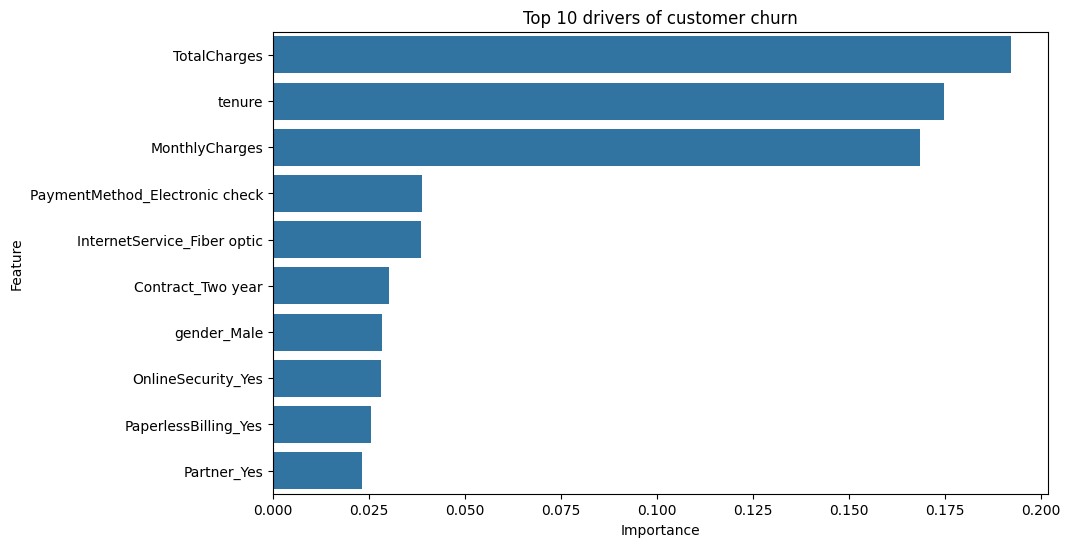

In [23]:
#extracting feature importance
importances = model.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df.head(10))

#graphical representation of feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 drivers of customer churn')
plt.show()